In [1]:
from typing import TypedDict, Optional
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI

In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
#State Definition
class LLMState(TypedDict):
    query: str
    answer: str

In [4]:
llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")

In [5]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate

parser = StrOutputParser()

def llm_ask(state: LLMState) -> LLMState:
    query = state["query"]
    prompt_template = PromptTemplate(
        template="You are a helpful assistant. Answer the following question to the point, don't answer with anything else but the answer: {query}",
        input_variables=["query"],
    )
    chain = prompt_template | llm | parser
    answer = chain.invoke({"query": query})
    state["answer"] = answer
    return state

In [6]:
#create graph
graph = StateGraph(LLMState)

#add nodes
graph.add_node("llm_query", llm_ask)

In [7]:
#add edges
graph.add_edge(START, "llm_query")
graph.add_edge("llm_query", END)

In [8]:
#compile graph
workflow = graph.compile()

In [9]:
query = "What is the capital of France?"
answer = ""
input_state = LLMState(query=query, answer=answer)

response = workflow.invoke(input_state)

In [10]:
print(f"query: {response['query']}")
print(f"answer: {response['answer']}")

query: What is the capital of France?
answer: Paris


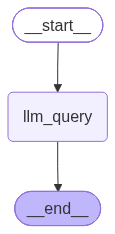

In [11]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())